In [ ]:
"""
STEP 2: Install required libraries for NER implementation.

spaCy         → Traditional NLP pipeline
transformers  → Hugging Face transformer models
torch         → Backend deep learning framework
pandas        → Data handling and tabular storage
datasets      → To load standard NER datasets (optional)
"""

!pip install spacy transformers torch pandas datasets
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 34.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
"""
STEP 3: Import all required libraries.

Each library serves a specific purpose in NER implementation.
"""

import spacy  # Industrial NLP library (tokenization, tagging, NER)
from spacy import displacy  # Used to visualize named entities

from transformers import (
    pipeline,  # High-level API for inference
    AutoTokenizer,  # Loads tokenizer of pretrained model
    AutoModelForTokenClassification  # Loads NER model
)

import torch  # Deep learning backend
import pandas as pd  # For storing results in DataFrame

In [ ]:
"""
STEP 4: Load spaCy pretrained English model.

The model contains:
- Tokenizer
- POS tagger
- Dependency parser
- Named Entity Recognizer (NER)
"""

# Load small English model
nlp = spacy.load("en_core_web_sm")

print("spaCy pipeline components:", nlp.pipe_names)

spaCy pipeline components: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


In [ ]:
"""
STEP 5: Create sample real-world sentences.

These sentences include:
- Political news
- Technology updates
- Sports events
- Business news
- International events
"""

sentences = [
    "Prime Minister Narendra Modi visited the United States in 2023.",
    "Apple Inc. launched the new iPhone 15 in California.",
    "Lionel Messi scored a goal for Inter Miami in the MLS final.",
    "Microsoft acquired OpenAI for billions of dollars.",
    "The Olympics 2024 will be held in Paris."
]

# Print sample sentences
for s in sentences:
    print(s)

Prime Minister Narendra Modi visited the United States in 2023.
Apple Inc. launched the new iPhone 15 in California.
Lionel Messi scored a goal for Inter Miami in the MLS final.
Microsoft acquired OpenAI for billions of dollars.
The Olympics 2024 will be held in Paris.


In [ ]:
"""
STEP 6: Apply spaCy NER on each sentence.

For every sentence:
- Process text using spaCy pipeline
- Extract entity text
- Extract entity label
"""

print("===== spaCy NER Results =====\n")

for sentence in sentences:
    # Process sentence through spaCy pipeline
    doc = nlp(sentence)

    print(f"Sentence: {sentence}")

    # Loop through detected entities
    for ent in doc.ents:
        print(f"Entity: {ent.text} | Label: {ent.label_}")

    print("-" * 60)

===== spaCy NER Results =====

Sentence: Prime Minister Narendra Modi visited the United States in 2023.
Entity: Narendra Modi | Label: PERSON
Entity: the United States | Label: GPE
Entity: 2023 | Label: DATE
------------------------------------------------------------
Sentence: Apple Inc. launched the new iPhone 15 in California.
Entity: Apple Inc. | Label: ORG
Entity: 15 | Label: CARDINAL
Entity: California | Label: GPE
------------------------------------------------------------
Sentence: Lionel Messi scored a goal for Inter Miami in the MLS final.
Entity: Lionel Messi | Label: PERSON
Entity: MLS | Label: ORG
------------------------------------------------------------
Sentence: Microsoft acquired OpenAI for billions of dollars.
Entity: Microsoft | Label: ORG
Entity: OpenAI | Label: ORG
Entity: billions of dollars | Label: MONEY
------------------------------------------------------------
Sentence: The Olympics 2024 will be held in Paris.
Entity: Paris | Label: GPE
-----------------

In [ ]:
"""
STEP 7: Store spaCy detected entities in a structured table.

Columns:
- Sentence
- Entity
- Label
"""

spacy_results = []  # Empty list to store results

for sentence in sentences:
    doc = nlp(sentence)

    for ent in doc.ents:
        # Append entity details
        spacy_results.append({
            "Sentence": sentence,
            "Entity": ent.text,
            "Label": ent.label_
        })

# Create DataFrame
spacy_df = pd.DataFrame(spacy_results)

# Display table
spacy_df

,Sentence,Entity,Label
0,Prime Minister Narendra Modi visited the Unite...,Narendra Modi,PERSON
1,Prime Minister Narendra Modi visited the Unite...,the United States,GPE
2,Prime Minister Narendra Modi visited the Unite...,2023,DATE
3,Apple Inc. launched the new iPhone 15 in Calif...,Apple Inc.,ORG
4,Apple Inc. launched the new iPhone 15 in Calif...,15,CARDINAL
5,Apple Inc. launched the new iPhone 15 in Calif...,California,GPE
6,Lionel Messi scored a goal for Inter Miami in ...,Lionel Messi,PERSON
7,Lionel Messi scored a goal for Inter Miami in ...,MLS,ORG
8,Microsoft acquired OpenAI for billions of doll...,Microsoft,ORG
9,Microsoft acquired OpenAI for billions of doll...,OpenAI,ORG


In [ ]:
"""
STEP 8: Visualize entities using displacy.

This will highlight entities with different colors:
PERSON → Orange
ORG    → Blue
GPE    → Green
DATE   → Purple
"""

# Visualize first sentence
displacy.render(nlp(sentences[0]), style="ent", jupyter=True)

In [ ]:
"""
STEP 9: Load pretrained Transformer model for token classification (NER).

Model used:
BERT-large fine-tuned on CoNLL-2003 dataset.
"""

model_name = "dbmdz/bert-large-cased-finetuned-conll03-english"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Load model
model = AutoModelForTokenClassification.from_pretrained(model_name)

# Create NER pipeline
ner_pipeline = pipeline("ner", model=model, tokenizer=tokenizer)

print("Transformer NER model loaded successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Transformer NER model loaded successfully!


In [ ]:
"""
STEP 10: Apply Hugging Face Transformer NER.

For each sentence:
- Pass into pipeline
- Extract token
- Extract entity label
- Extract confidence score
"""

print("===== Hugging Face NER Results =====\n")

for sentence in sentences:

    results = ner_pipeline(sentence)

    print(f"Sentence: {sentence}")

    for r in results:
        print(f"Word: {r['word']} | Label: {r['entity']} | Score: {round(r['score'], 3)}")

    print("-" * 60)

===== Hugging Face NER Results =====

Sentence: Prime Minister Narendra Modi visited the United States in 2023.
Word: Na | Label: I-PER | Score: 0.9990000128746033
Word: ##ren | Label: I-PER | Score: 0.9929999709129333
Word: ##dra | Label: I-PER | Score: 0.9990000128746033
Word: Mo | Label: I-PER | Score: 0.9990000128746033
Word: ##di | Label: I-PER | Score: 0.9869999885559082
Word: United | Label: I-LOC | Score: 1.0
Word: States | Label: I-LOC | Score: 1.0
------------------------------------------------------------
Sentence: Apple Inc. launched the new iPhone 15 in California.
Word: Apple | Label: I-ORG | Score: 0.9990000128746033
Word: Inc | Label: I-ORG | Score: 0.9990000128746033
Word: iPhone | Label: I-MISC | Score: 0.9950000047683716
Word: 15 | Label: I-MISC | Score: 0.9950000047683716
Word: California | Label: I-LOC | Score: 1.0
------------------------------------------------------------
Sentence: Lionel Messi scored a goal for Inter Miami in the MLS final.
Word: Lionel | Labe

In [ ]:
"""
STEP 11: Clean Transformer output.

Problem:
Transformer splits words into subwords (##).

Solution:
- Remove '##'
- Store clean entity names
- Save into DataFrame
"""

hf_results = []

for sentence in sentences:
    results = ner_pipeline(sentence)

    for r in results:
        # Remove subword token markers
        clean_word = r["word"].replace("##", "")

        hf_results.append({
            "Sentence": sentence,
            "Entity": clean_word,
            "Label": r["entity"],
            "Confidence Score": round(r["score"], 3)
        })

# Create DataFrame
hf_df = pd.DataFrame(hf_results)

hf_df

,Sentence,Entity,Label,Confidence Score
0,Prime Minister Narendra Modi visited the Unite...,Na,I-PER,0.999
1,Prime Minister Narendra Modi visited the Unite...,ren,I-PER,0.993
2,Prime Minister Narendra Modi visited the Unite...,dra,I-PER,0.999
3,Prime Minister Narendra Modi visited the Unite...,Mo,I-PER,0.999
4,Prime Minister Narendra Modi visited the Unite...,di,I-PER,0.987
5,Prime Minister Narendra Modi visited the Unite...,United,I-LOC,1.000
6,Prime Minister Narendra Modi visited the Unite...,States,I-LOC,1.000
7,Apple Inc. launched the new iPhone 15 in Calif...,Apple,I-ORG,0.999
8,Apple Inc. launched the new iPhone 15 in Calif...,Inc,I-ORG,0.999
9,Apple Inc. launched the new iPhone 15 in Calif...,iPhone,I-MISC,0.995


In [ ]:
"""
STEP 12: Create comparison table between spaCy and Transformer.
"""

comparison_data = {
    "Feature": [
        "Model Type",
        "Speed",
        "Accuracy (Qualitative)",
        "Context Handling",
        "Confidence Score",
        "Hardware Requirement"
    ],
    "spaCy": [
        "Statistical + CNN",
        "Very Fast",
        "Good",
        "Limited",
        "Not Provided",
        "CPU"
    ],
    "Hugging Face": [
        "Transformer (BERT)",
        "Slower",
        "Very High",
        "Excellent",
        "Provided",
        "GPU Recommended"
    ]
}

comparison_df = pd.DataFrame(comparison_data)

comparison_df

,Feature,spaCy,Hugging Face
0,Model Type,Statistical + CNN,Transformer (BERT)
1,Speed,Very Fast,Slower
2,Accuracy (Qualitative),Good,Very High
3,Context Handling,Limited,Excellent
4,Confidence Score,Not Provided,Provided
5,Hardware Requirement,CPU,GPU Recommended


In [ ]:
"""
Optional: Evaluate using seqeval library for F1-score.
"""

!pip install seqeval

from seqeval.metrics import classification_report, f1_score

# Example dummy evaluation (replace with real labels if dataset used)
true_labels = [["B-PER", "O", "B-LOC"]]
pred_labels = [["B-PER", "O", "B-LOC"]]

print("F1 Score:", f1_score(true_labels, pred_labels))
print(classification_report(true_labels, pred_labels))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=ca24941670f7d5cf9ab8a4fd6881b445765727e01713a3b12e4f95da6b1d1d56
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval
F1 Score: 1.0
              precision    recall  f1-score   support

         LOC       1.00      1.00      1.00         1
         PER       1.00      1.00      1.00         1

   micro avg       1.00      1.00      1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [ ]:

"""
STEP 14: Manual Error Analysis Template.

Students should inspect incorrect predictions manually.
"""

# Example incorrect case
sentence = "Microsoft acquired OpenAI for billions of dollars."
print("Sentence:", sentence)

print("\nspaCy Output:")
print([(ent.text, ent.label_) for ent in nlp(sentence).ents])

print("\nTransformer Output:")
print(ner_pipeline(sentence))

Sentence: Microsoft acquired OpenAI for billions of dollars.

spaCy Output:
[('Microsoft', 'ORG'), ('OpenAI', 'ORG'), ('billions of dollars', 'MONEY')]

Transformer Output:
[{'entity': 'I-ORG', 'score': np.float32(0.99959713), 'index': 1, 'word': 'Microsoft', 'start': 0, 'end': 9}, {'entity': 'I-ORG', 'score': np.float32(0.99924576), 'index': 3, 'word': 'Open', 'start': 19, 'end': 23}, {'entity': 'I-ORG', 'score': np.float32(0.9979517), 'index': 4, 'word': '##A', 'start': 23, 'end': 24}, {'entity': 'I-ORG', 'score': np.float32(0.99775606), 'index': 5, 'word': '##I', 'start': 24, 'end': 25}]


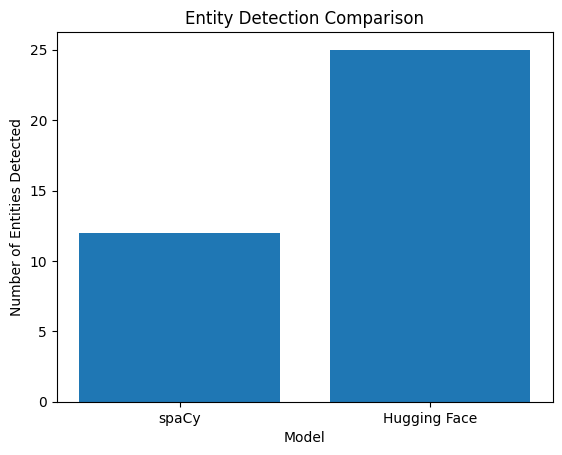

In [ ]:
"""
Graph 1: Compare total number of entities detected
by spaCy and Hugging Face Transformer.
"""

import matplotlib.pyplot as plt

# Count number of detected entities
spacy_count = len(spacy_df)
hf_count = len(hf_df)

# Create bar graph
plt.figure()
plt.bar(["spaCy", "Hugging Face"], [spacy_count, hf_count])

plt.xlabel("Model")
plt.ylabel("Number of Entities Detected")
plt.title("Entity Detection Comparison")

plt.show()